# Bitcoin — ARIMA • GARCH(1,1) • EVT (2012–2026)

This notebook follows the pipeline described in `Memoire_statistique.pdf`:
- data acquisition and daily resampling
- ARIMA for trend/non-stationarity
- GARCH(1,1) for conditional volatility
- EVT for extreme losses + risk metrics (VaR / ES)

All figures are saved to `crypto/figures/` (relative to this notebook).

## 0) Setup

Install dependencies if needed (recommended in a virtualenv):

```bash
pip install kagglehub[pandas-datasets] statsmodels arch scipy matplotlib seaborn scikit-learn jupyter
```

Then run the imports and configuration below.

In [8]:
# Optional (Colab-style): uncomment if you want to install from inside the notebook
#!pip install kagglehub[pandas-datasets] statsmodels arch scipy matplotlib seaborn scikit-learn

In [9]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR

from arch import arch_model
from scipy.stats import genextreme

warnings.filterwarnings("ignore")

# --------------------------------
# Plotting / reproducibility setup
# --------------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

def savefig(name: str) -> None:
    """Save the current Matplotlib figure to ./figures."""
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight")

## 1) Data acquisition (Kaggle)

We download a historical Bitcoin dataset via `kagglehub`, then load the CSV into a DataFrame.

In [10]:
import kagglehub

print("--- Downloading Bitcoin dataset (Kaggle) ---")

DATA_DIR = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
print("Downloaded to:", DATA_DIR)

files = os.listdir(DATA_DIR)
csv_filename = next(f for f in files if f.endswith(".csv"))
CSV_PATH = os.path.join(DATA_DIR, csv_filename)
print("CSV:", CSV_PATH)

df_raw = pd.read_csv(CSV_PATH)
display(df_raw.head())

--- Downloading Bitcoin dataset (Kaggle) ---


100%|██████████| 101M/101M [00:02<00:00, 37.7MB/s] 

Extracting files...


Downloaded to: /home/hubertl/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/553
CSV: /home/hubertl/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/553/btcusd_1-min_data.csv


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


## 2) Data preparation

We resample to daily frequency and compute log-returns.

--- Data preparation ---
Columns: ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']


,Close,Volume,Log_Returns
Timestamp,,,
2012-01-02,5.00,10.100000,0.032523
2012-01-03,5.29,107.085281,0.056380
2012-01-04,5.57,107.233260,0.051577
2012-01-05,6.42,70.328742,0.142023
2012-01-06,6.40,55.855834,-0.003120


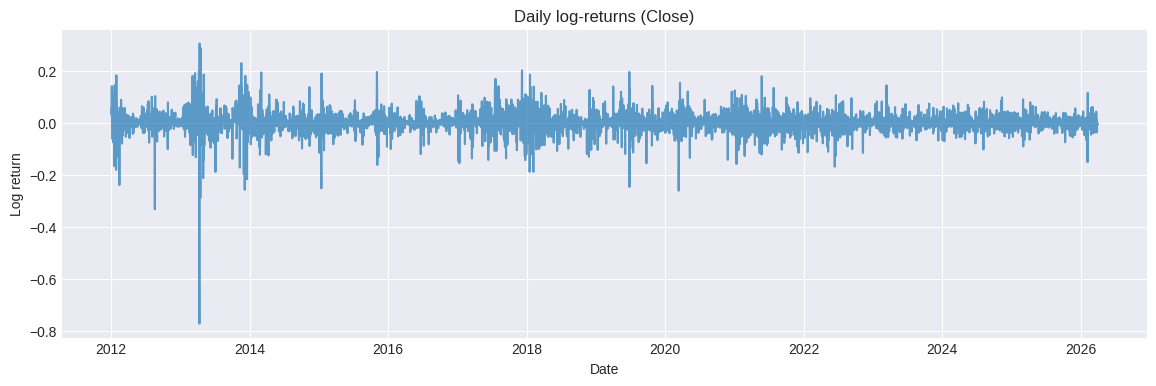

In [11]:
print("--- Data preparation ---")

df = df_raw.copy()
print("Columns:", df.columns.tolist())

# 1) Timestamp parsing
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")
    df = df.set_index("Timestamp")
elif "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
else:
    raise ValueError("Could not find a 'Timestamp' or 'Date' column")

# 2) Use Close price and basic cleanup
df["Close"] = df["Close"].ffill()

# Detect volume column name (varies by dataset)
vol_col = "Volume_(BTC)" if "Volume_(BTC)" in df.columns else "Volume"
if vol_col in df.columns:
    df[vol_col] = df[vol_col].fillna(0)

# 3) Resample to daily data: last close, sum volume
df_daily = df["Close"].resample("D").last().to_frame()
if vol_col in df.columns:
    df_daily["Volume"] = df[vol_col].resample("D").sum()

df_daily = df_daily.dropna()

# 4) Log returns
df_daily["Log_Returns"] = np.log(df_daily["Close"] / df_daily["Close"].shift(1))
df_daily = df_daily.dropna()

display(df_daily.head())

# Plot log-returns
plt.figure(figsize=(14, 4))
plt.plot(df_daily.index, df_daily["Log_Returns"], color="tab:blue", alpha=0.7)
plt.title("Daily log-returns (Close)")
plt.xlabel("Date")
plt.ylabel("Log return")
savefig("01_daily_log_returns.png")
plt.show()

## 3) ARIMA (trend / non-stationarity)

We fit an ARIMA(1,1,1) model on the log-price and inspect residuals.

--- ARIMA(1,1,1) on log-price ---
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5202
Model:                 ARIMA(1, 1, 1)   Log Likelihood                9167.644
Date:                Mon, 30 Mar 2026   AIC                         -18329.288
Time:                        14:04:39   BIC                         -18309.618
Sample:                    01-02-2012   HQIC                        -18322.408
                         - 03-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3037      4.131      0.074      0.941      -7.794       8.401
ma.L1         -0.3053      4.130     -0.074      0.941      -8.401       7.790
sigma2         0.0

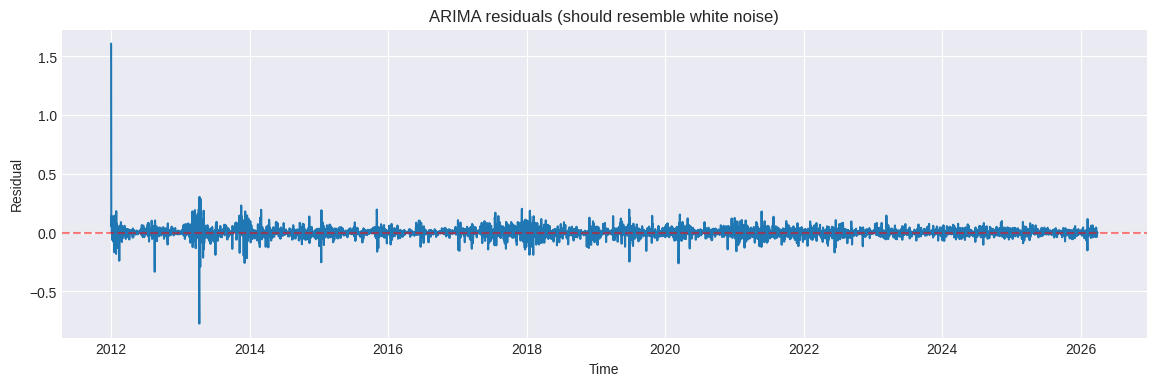

In [12]:
print("--- ARIMA(1,1,1) on log-price ---")

log_price = np.log(df_daily["Close"])

arima_model = ARIMA(log_price, order=(1, 1, 1))
arima_result = arima_model.fit()

print(arima_result.summary())

# Residual plot
plt.figure(figsize=(14, 4))
plt.plot(arima_result.resid, color="tab:blue")
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.title("ARIMA residuals (should resemble white noise)")
plt.xlabel("Time")
plt.ylabel("Residual")
savefig("02_arima_residuals.png")
plt.show()

## 4) GARCH(1,1) (conditional volatility)

We model volatility clustering on daily returns with a GARCH(1,1) model.

--- GARCH(1,1) on daily returns ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13625.4
Distribution:                  Normal   AIC:                           27258.8
Method:            Maximum Likelihood   BIC:                           27285.1
                                        No. Observations:                 5202
Date:                Mon, Mar 30 2026   Df Residuals:                     5201
Time:                        14:04:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1208  3.846

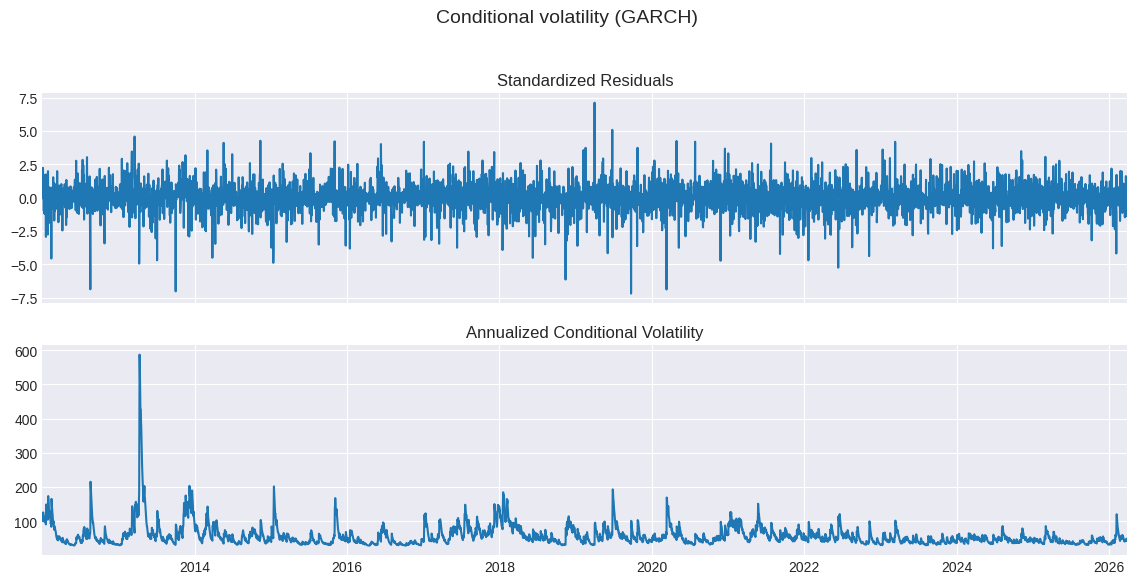

In [13]:
print("--- GARCH(1,1) on daily returns ---")

# GARCH often works better numerically on percentage returns
returns_scaled = df_daily["Log_Returns"] * 100

garch_model = arch_model(returns_scaled, vol="GARCH", p=1, q=1, mean="Constant")
garch_result = garch_model.fit(disp="off")
print(garch_result.summary())

# arch_model has its own plot helper; we capture the figure and save it
fig = garch_result.plot(annualize="D")
fig.set_size_inches(14, 6)
plt.suptitle("Conditional volatility (GARCH)", y=1.02, fontsize=14)
plt.savefig(os.path.join(FIG_DIR, "03_garch_conditional_volatility.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5) Optional: VAR (returns + volume)

If volume is available, we fit a small VAR model and plot an impulse response function (IRF).

--- VAR model (multivariate) ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     14:04:40
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -7.24580
Nobs:                     5198.00    HQIC:                  -7.25729
Log likelihood:           4140.45    FPE:                0.000700678
AIC:                     -7.26346    Det(Omega_mle):     0.000698795
--------------------------------------------------------------------
Results for equation Returns
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.001915         0.000575            3.329           0.001
L1.Returns                 0.012221         0.013872            0.881           0.378
L1.Lo

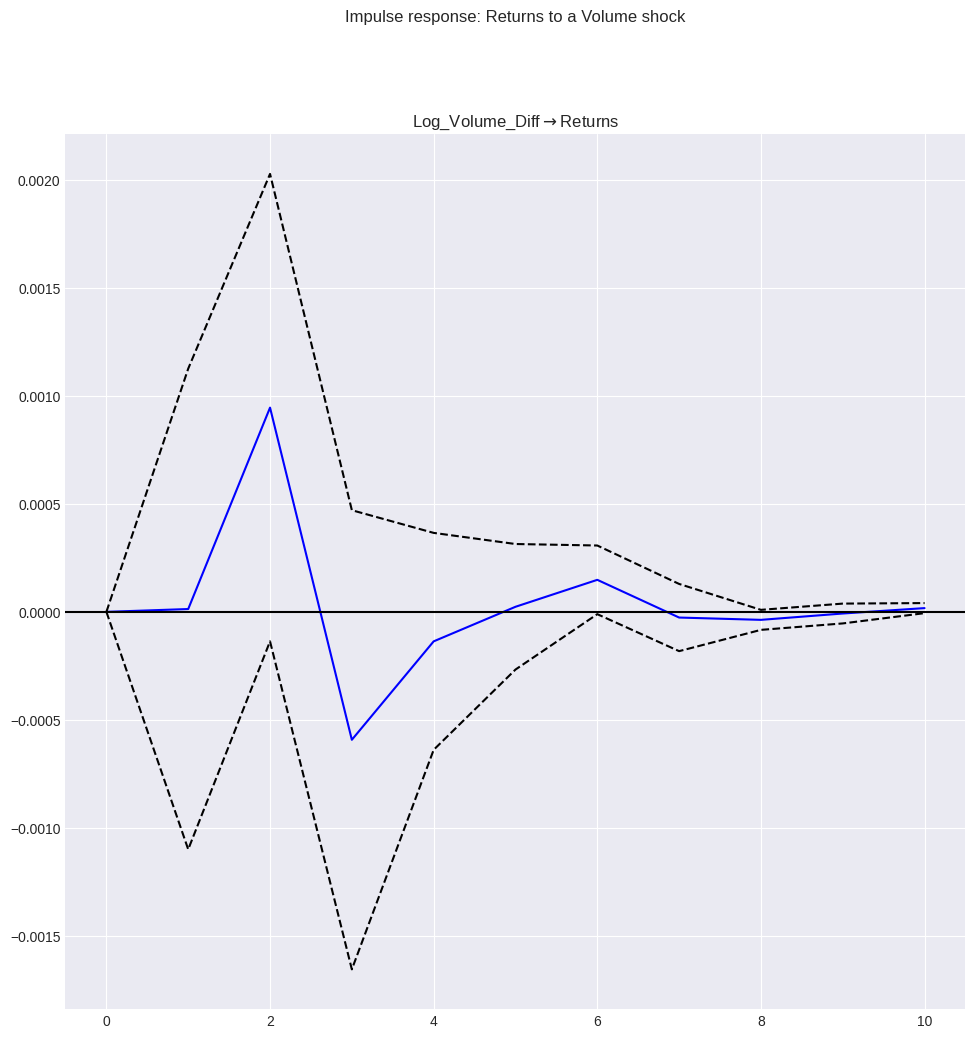

In [14]:
print("--- VAR model (multivariate) ---")

if "Volume" in df_daily.columns:
    df_var = pd.DataFrame({
        "Returns": df_daily["Log_Returns"],
        "Log_Volume_Diff": np.log(df_daily["Volume"] + 1).diff(),
    }).dropna()

    model_var = VAR(df_var)
    var_result = model_var.fit(3)
    print(var_result.summary())

    irf = var_result.irf(10)  # 10 days
    fig = irf.plot(orth=True, impulse="Log_Volume_Diff", response="Returns")
    plt.suptitle("Impulse response: Returns to a Volume shock", y=1.05)
    plt.savefig(os.path.join(FIG_DIR, "04_var_irf.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No Volume column: skipping VAR.")

## 6) EVT (extreme losses)

We focus on extreme *losses* and fit a GEV distribution to monthly block maxima of losses.

--- EVT via block maxima (monthly) ---
GEV fit parameters:
- shape (xi) = -0.2821
- loc (mu)   = 0.0552
- scale (s)  = 0.0325


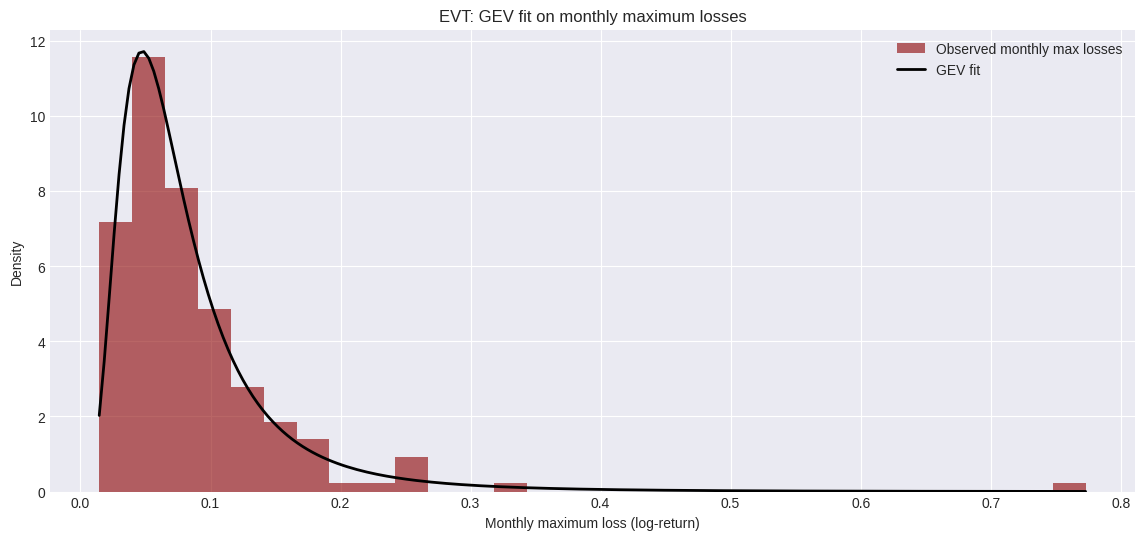

In [15]:
print("--- EVT via block maxima (monthly) ---")

# Losses are negative returns
losses = -df_daily["Log_Returns"]

# Monthly block maxima of losses (month-end)
monthly_max_losses = losses.resample("ME").max().dropna()

shape, loc, scale = genextreme.fit(monthly_max_losses)
print(
    "GEV fit parameters:\n"
    f"- shape (xi) = {shape:.4f}\n"
    f"- loc (mu)   = {loc:.4f}\n"
    f"- scale (s)  = {scale:.4f}"
)

plt.figure(figsize=(14, 6))
plt.hist(
    monthly_max_losses,
    bins=30,
    density=True,
    alpha=0.6,
    color="darkred",
    label="Observed monthly max losses",
 )

x = np.linspace(monthly_max_losses.min(), monthly_max_losses.max(), 200)
plt.plot(x, genextreme.pdf(x, shape, loc, scale), "k-", lw=2, label="GEV fit")

plt.title("EVT: GEV fit on monthly maximum losses")
plt.xlabel("Monthly maximum loss (log-return)")
plt.ylabel("Density")
plt.legend()
savefig("05_evt_gev_fit.png")
plt.show()

## 7) Backtesting (hold-out evaluation)

We keep the last 90 days as a test set and evaluate ARIMA forecasts and GARCH/EVT-based risk signals.

--- Backtesting ARIMA (last 90 days) ---
Train length: 5112 days
Test length : 90 days
RMSE (log-scale): 0.2025


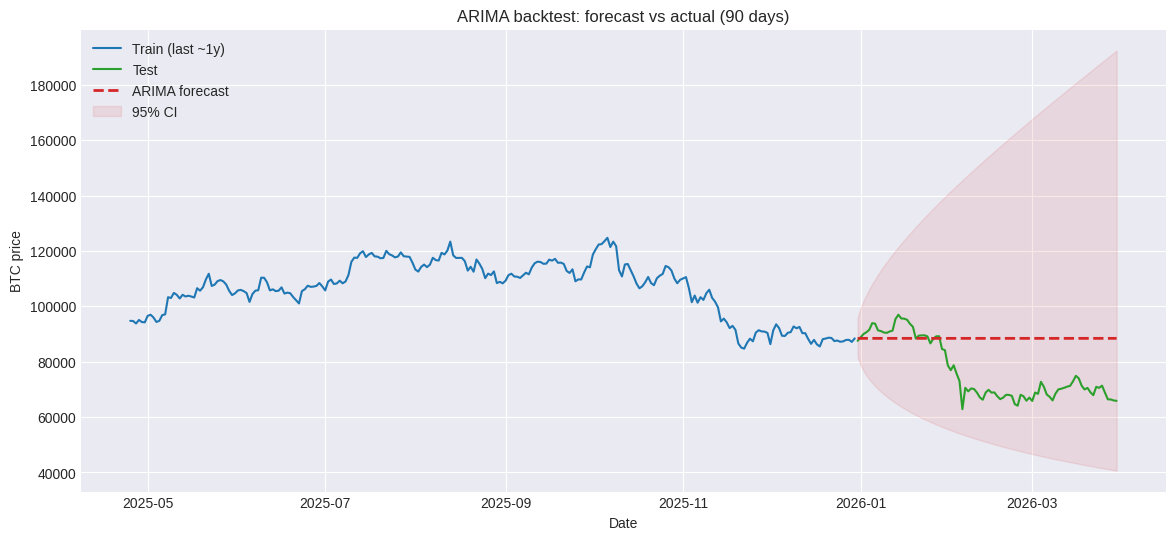

In [16]:
from sklearn.metrics import mean_squared_error

print("--- Backtesting ARIMA (last 90 days) ---")

data = np.log(df_daily["Close"]).dropna()

n_test = 90
train = data.iloc[:-n_test]
test = data.iloc[-n_test:]

print(f"Train length: {len(train)} days")
print(f"Test length : {len(test)} days")

model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

forecast = fitted_model.forecast(steps=n_test)
forecast.index = test.index

rmse = float(np.sqrt(mean_squared_error(test, forecast)))
print(f"RMSE (log-scale): {rmse:.4f}")

train_price = np.exp(train)
test_price = np.exp(test)
forecast_price = np.exp(forecast)

plt.figure(figsize=(14, 6))
plt.plot(train_price.iloc[-250:], label="Train (last ~1y)", color="tab:blue")
plt.plot(test_price, label="Test", color="tab:green")
plt.plot(forecast_price, label="ARIMA forecast", color="tab:red", linestyle="--", linewidth=2)

pred_summary = fitted_model.get_forecast(steps=n_test).summary_frame()
conf_int_lower = np.exp(pred_summary["mean_ci_lower"])
conf_int_upper = np.exp(pred_summary["mean_ci_upper"])
plt.fill_between(test.index, conf_int_lower, conf_int_upper, color="tab:red", alpha=0.1, label="95% CI")

plt.title("ARIMA backtest: forecast vs actual (90 days)")
plt.xlabel("Date")
plt.ylabel("BTC price")
plt.legend()
savefig("06_arima_backtest.png")
plt.show()

--- Backtesting GARCH & EVT (last 90 days) ---
Train length: 5112 days
Test length : 90 days
1) GARCH volatility forecast


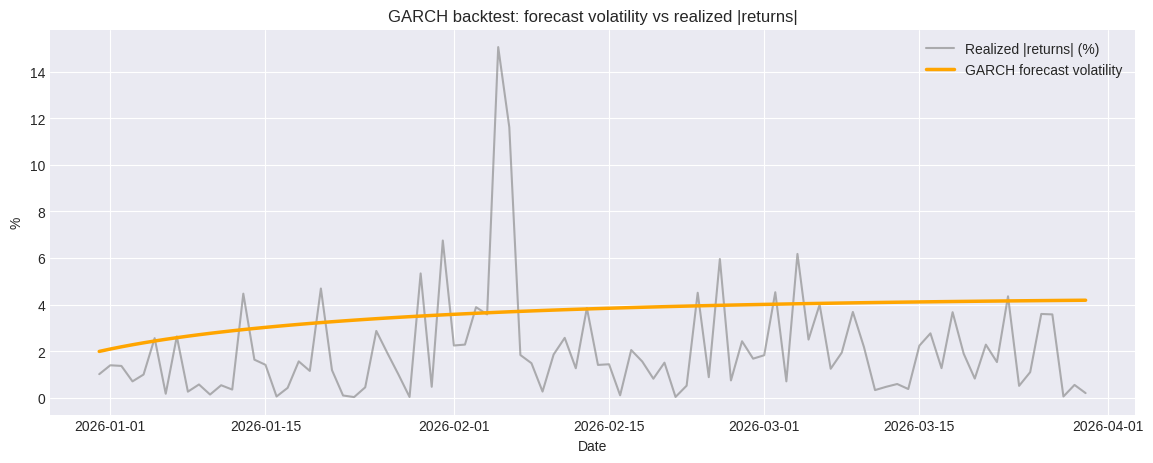

2) EVT validation
------------------------------------------------------------
EVT predicted worst monthly loss over this horizon: -8.48%
Observed worst daily loss in test (90d):          -13.98%
------------------------------------------------------------


In [17]:
print("--- Backtesting GARCH & EVT (last 90 days) ---")

n_test = 90
returns_scaled = df_daily["Log_Returns"] * 100
train_ret = returns_scaled.iloc[:-n_test]
test_ret = returns_scaled.iloc[-n_test:]

print(f"Train length: {len(train_ret)} days")
print(f"Test length : {len(test_ret)} days")

# ---------------------------
# 1) GARCH volatility forecast
# ---------------------------
print("1) GARCH volatility forecast")
garch_model_bt = arch_model(train_ret, vol="GARCH", p=1, q=1, mean="Constant")
garch_res = garch_model_bt.fit(disp="off")

garch_forecast = garch_res.forecast(horizon=n_test)
pred_volatility = np.sqrt(garch_forecast.variance.iloc[-1].values)
realized_volatility = np.abs(test_ret.values)

plt.figure(figsize=(14, 5))
plt.plot(test_ret.index, realized_volatility, color="grey", alpha=0.6, label="Realized |returns| (%)")
plt.plot(test_ret.index, pred_volatility, color="orange", linewidth=2.5, label="GARCH forecast volatility")
plt.title("GARCH backtest: forecast volatility vs realized |returns|")
plt.xlabel("Date")
plt.ylabel("%")
plt.legend()
savefig("07_garch_backtest_volatility.png")
plt.show()

# ---------------------------
# 2) EVT: block maxima on train
# ---------------------------
print("2) EVT validation")
train_losses = -train_ret / 100.0
monthly_max_losses_train = train_losses.resample("ME").max().dropna()

shape_t, loc_t, scale_t = genextreme.fit(monthly_max_losses_train)

# Return level for ~3 months (rough horizon for 90 days)
p_quarter = 1 - (1 / 3)
worst_monthly_loss_pred = genextreme.ppf(p_quarter, shape_t, loc=loc_t, scale=scale_t)
worst_monthly_loss_pred_pct = (1 - np.exp(-worst_monthly_loss_pred)) * 100

worst_daily_loss_test_pct = -float(test_ret.min())
worst_daily_loss_test_pct_geom = (1 - np.exp(-worst_daily_loss_test_pct / 100.0)) * 100

print("-" * 60)
print(f"EVT predicted worst monthly loss over this horizon: -{worst_monthly_loss_pred_pct:.2f}%")
print(f"Observed worst daily loss in test (90d):          -{worst_daily_loss_test_pct_geom:.2f}%")
print("-" * 60)

## 8) Parameter significance (p-values)

Quick sanity-check on which fitted parameters are statistically significant (at 5%).

In [18]:
print("--- Statistical check: parameter p-values ---")

alpha_sig = 0.05

def analyse_pvalues(pvalues, model_name: str) -> None:
    print(f"\n[{model_name}]")
    print("-" * 60)
    for param, pval in pvalues.items():
        status = "significant" if pval < alpha_sig else "not significant"
        print(f"{param:<15} p={pval:.4g}  -> {status}")
    print("-" * 60)

# ARIMA p-values
try:
    analyse_pvalues(fitted_model.pvalues, "ARIMA")
except NameError:
    print("ARIMA model not found: run the ARIMA backtest cell first.")

# GARCH p-values
try:
    analyse_pvalues(garch_res.pvalues, "GARCH")
except NameError:
    print("GARCH model (garch_res) not found: run the GARCH backtest cell first.")

--- Statistical check: parameter p-values ---

[ARIMA]
------------------------------------------------------------
ar.L1           p=0.9208  -> not significant
ma.L1           p=0.9217  -> not significant
sigma2          p=0  -> significant
------------------------------------------------------------

[GARCH]
------------------------------------------------------------
mu              p=0.001422  -> significant
omega           p=0.0003009  -> significant
alpha[1]        p=2.842e-10  -> significant
beta[1]         p=3.416e-236  -> significant
------------------------------------------------------------


## 9) Risk report (1-day horizon): VaR & Expected Shortfall

We compute VaR/ES at 99% confidence using:
- a historical (empirical) approach,
- a parametric approach using the next-day volatility forecast from GARCH.

Risk report (1-day horizon): VaR & ES

--- Historical ---
VaR 99% : -11.95%   (≈ $1,194.97)
ES  99% : -18.40%   (≈ $1,840.21)

--- GARCH (Normal, next-day) ---
VaR 99% : -5.93%   (≈ $593.37)
ES  99% : -6.82%   (≈ $681.56)



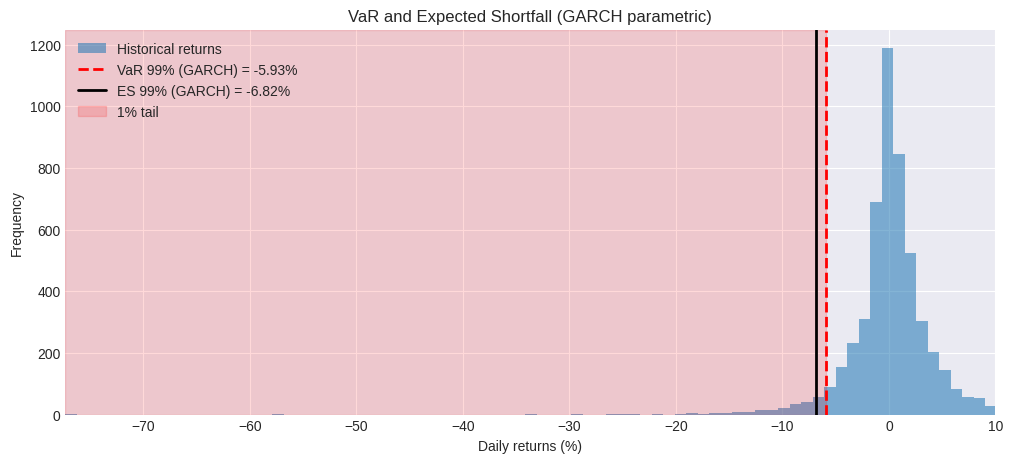

In [19]:
import scipy.stats as stats

print("======================================================")
print("Risk report (1-day horizon): VaR & ES")
print("======================================================\n")

portfolio_value = 10_000
confidence = 0.99
alpha = 1 - confidence

returns_pct = df_daily["Log_Returns"].dropna() * 100

# 1) Historical method
var_99_hist = np.percentile(returns_pct, alpha * 100)
es_99_hist = returns_pct[returns_pct <= var_99_hist].mean()

# 2) GARCH parametric (Normal) for next-day forecast
garch_fc_1d = garch_result.forecast(horizon=1)
mu_next = float(garch_fc_1d.mean.iloc[-1, 0])
sigma_next = float(np.sqrt(garch_fc_1d.variance.iloc[-1, 0]))

z = float(stats.norm.ppf(alpha))
var_99_garch = mu_next + sigma_next * z
es_99_garch = mu_next - sigma_next * (stats.norm.pdf(z) / alpha)

def print_metrics(method: str, var_pct: float, es_pct: float, capital: float) -> None:
    var_usd = capital * (abs(var_pct) / 100)
    es_usd = capital * (abs(es_pct) / 100)
    print(f"--- {method} ---")
    print(f"VaR 99% : {var_pct:.2f}%   (≈ ${var_usd:,.2f})")
    print(f"ES  99% : {es_pct:.2f}%   (≈ ${es_usd:,.2f})")
    print("")

print_metrics("Historical", float(var_99_hist), float(es_99_hist), portfolio_value)
print_metrics("GARCH (Normal, next-day)", var_99_garch, es_99_garch, portfolio_value)

# Visualization
plt.figure(figsize=(12, 5))
plt.hist(returns_pct, bins=100, alpha=0.55, color="tab:blue", label="Historical returns")
plt.axvline(var_99_garch, color="red", linestyle="--", linewidth=2, label=f"VaR 99% (GARCH) = {var_99_garch:.2f}%")
plt.axvline(es_99_garch, color="black", linestyle="-", linewidth=2, label=f"ES 99% (GARCH) = {es_99_garch:.2f}%")
plt.axvspan(returns_pct.min(), var_99_garch, color="red", alpha=0.15, label="1% tail")

plt.title("VaR and Expected Shortfall (GARCH parametric)")
plt.xlabel("Daily returns (%)")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(float(returns_pct.min()), 10)
savefig("08_var_es.png")
plt.show()

## 10) Diagnostics (residual tests)

We check whether residuals behave as expected (no autocorrelation for ARIMA; remaining heavy tails / ARCH effects, etc.).

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

print("======================================================")
print("Diagnostics (residual tests)")
print("======================================================\n")

alpha = 0.05

# ARIMA residuals (drop first element to avoid initialization artefact)
resid_arima = arima_result.resid.iloc[1:].dropna()

# Standardized GARCH residuals
resid_garch_std = (garch_result.resid / garch_result.conditional_volatility).dropna()

# 1) Ljung-Box on ARIMA residuals
print("--- 1) Ljung-Box test (ARIMA residual autocorrelation) ---")
lb = acorr_ljungbox(resid_arima, lags=[10], return_df=True)
lb_p = float(lb["lb_pvalue"].iloc[0])
print(f"p-value = {lb_p:.4f}")
if lb_p > alpha:
    print("-> OK: cannot reject no-autocorrelation (residuals ~ white noise).")
else:
    print("-> Warning: residual autocorrelation remains (ARIMA could be improved).")
print("")

# 2) Jarque-Bera normality test on standardized GARCH residuals
print("--- 2) Jarque-Bera test (normality of standardized GARCH residuals) ---")
jb_stat, jb_p = jarque_bera(resid_garch_std)
jb_p = float(jb_p)
print(f"p-value = {jb_p:.4f}")
if jb_p > alpha:
    print("-> Cannot reject normality (unusual for crypto, but possible on some windows).")
else:
    print("-> Reject normality: heavy tails remain (motivates EVT).")
print("")

# 3) ARCH-LM test on standardized residuals
print("--- 3) ARCH-LM test (remaining ARCH effects after GARCH) ---")
arch_test = het_arch(resid_garch_std, nlags=5)
arch_p = float(arch_test[1])
print(f"p-value = {arch_p:.4f}")
if arch_p > alpha:
    print("-> OK: no remaining ARCH effects detected.")
else:
    print("-> Warning: remaining ARCH effects (consider richer volatility models).")

Diagnostics (residual tests)

--- 1) Ljung-Box test (ARIMA residual autocorrelation) ---
p-value = 0.0000
-> Warning: residual autocorrelation remains (ARIMA could be improved).

--- 2) Jarque-Bera test (normality of standardized GARCH residuals) ---
p-value = 0.0000
-> Reject normality: heavy tails remain (motivates EVT).

--- 3) ARCH-LM test (remaining ARCH effects after GARCH) ---
p-value = 0.0812
-> OK: no remaining ARCH effects detected.


## 11) Takeaways

- Crypto markets exhibit strong volatility clustering and heavy tails; ARIMA captures only part of the dynamics.
- GARCH helps forecast short-horizon conditional volatility, but residuals can remain non-Gaussian.
- EVT complements GARCH by focusing specifically on the tail behavior (extreme losses), which is what matters for VaR/ES.